<a href="https://colab.research.google.com/github/Fushionek/MLTraining/blob/main/Supervised/basics/Backward_Elimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

sns.set()
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
sklearn.__version__


'1.6.1'

In [3]:
df_raw = pd.read_csv('https://storage.googleapis.com/esmartdata-courses-files/ml-course/insurance.csv')
df_raw.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df = df_raw.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [6]:
df[df['charges'] == 1639.5631]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [7]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [8]:
cat_cols = [col for col in df.columns if df[col].dtype == 'O']
cat_cols

['sex', 'smoker', 'region']

In [10]:
for col in cat_cols:
  df[col] = df[col].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   category
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   category
 5   region    1337 non-null   category
 6   charges   1337 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 56.6 KB


In [13]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [15]:
df.describe(include='category').T

,count,unique,top,freq
sex,1337,2,male,675
smoker,1337,2,no,1063
region,1337,4,southeast,364


In [16]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


<Axes: ylabel='count'>

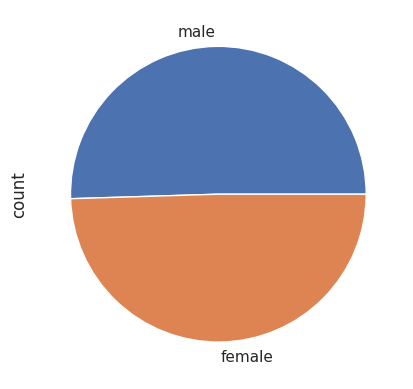

In [18]:
df.sex.value_counts().plot(kind='pie')

<Axes: ylabel='count'>

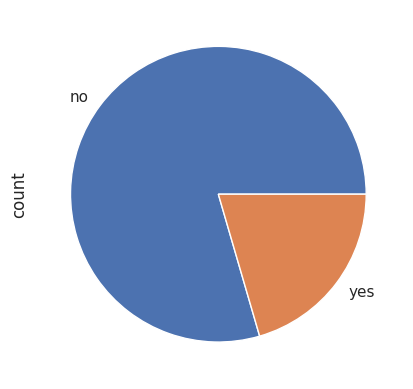

In [20]:
df.smoker.value_counts().plot(kind='pie')

<Axes: ylabel='count'>

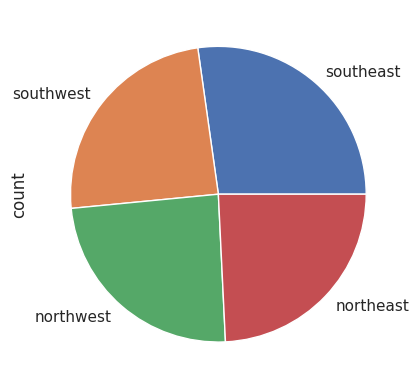

In [21]:
df.region.value_counts().plot(kind='pie')

<Axes: ylabel='Frequency'>

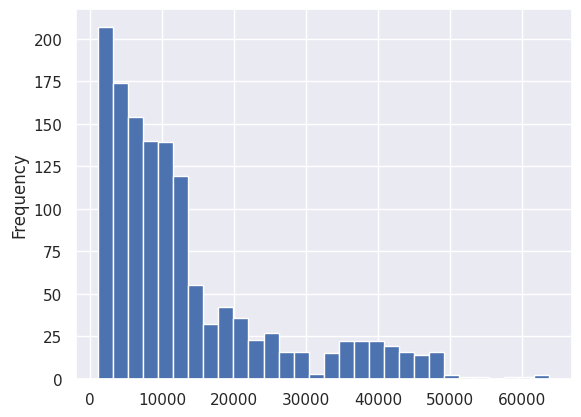

In [22]:
df.charges.plot(kind='hist', bins=30)

In [23]:
import plotly.express as px
px.histogram(df, x='charges', width=700, height=400, nbins=50,facet_col='smoker',facet_row='sex')

In [24]:
px.histogram(df, x='smoker', facet_col='sex', color='sex', width=700, height=400)

In [27]:
df_dummies = pd.get_dummies(df, drop_first=True)
df_dummies

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [29]:
correlation = df_dummies.corr()
correlation

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
age,1.000000,0.109344,0.041536,0.298308,-0.019814,-0.025587,0.001495,-0.012311,0.009415
bmi,0.109344,1.000000,0.012755,0.198401,0.046397,0.003746,-0.136138,0.270057,-0.006211
children,0.041536,0.012755,1.000000,0.067389,0.017848,0.007331,0.026044,-0.023492,0.021538
charges,0.298308,0.198401,0.067389,1.000000,0.058044,0.787234,-0.038695,0.073578,-0.043637
sex_male,-0.019814,0.046397,0.017848,0.058044,1.000000,0.076596,-0.012482,0.017578,-0.003767
smoker_yes,-0.025587,0.003746,0.007331,0.787234,0.076596,1.000000,-0.036321,0.068282,-0.037168
region_northwest,0.001495,-0.136138,0.026044,-0.038695,-0.012482,-0.036321,1.000000,-0.345909,-0.320493
region_southeast,-0.012311,0.270057,-0.023492,0.073578,0.017578,0.068282,-0.345909,1.000000,-0.346614
region_southwest,0.009415,-0.006211,0.021538,-0.043637,-0.003767,-0.037168,-0.320493,-0.346614,1.000000


<Axes: >

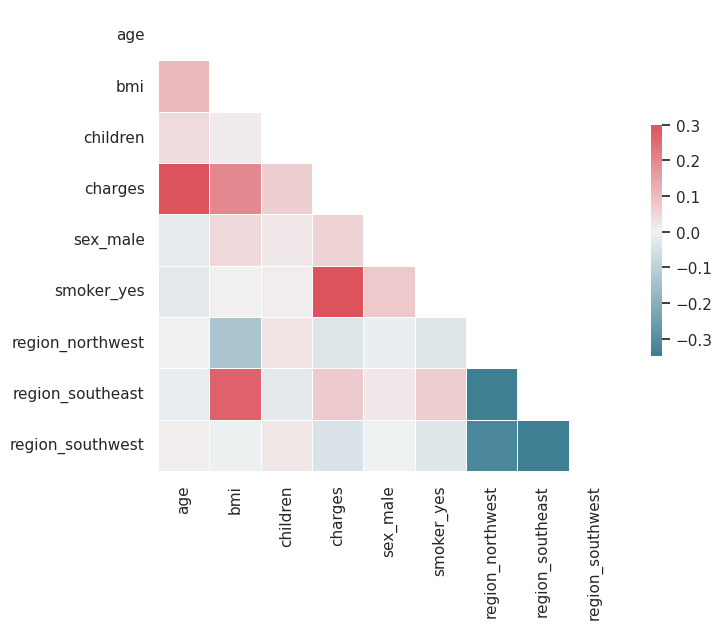

In [32]:
sns.set(style="white")
mask = np.zeros_like(correlation, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(8, 6))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(correlation, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [34]:
df_dummies.corr()['charges'].sort_values(ascending=False)

,charges
charges,1.000000
smoker_yes,0.787234
age,0.298308
bmi,0.198401
region_southeast,0.073578
children,0.067389
sex_male,0.058044
region_northwest,-0.038695
region_southwest,-0.043637


<Axes: >

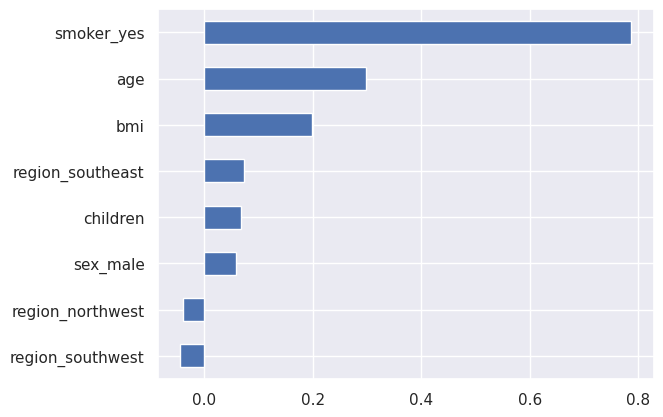

In [35]:
sns.set()
df_dummies.corr()['charges'].sort_values()[:-1].plot(kind='barh')

In [36]:
data = df_dummies.copy()
target = data.pop('charges')
data.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [37]:
target.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (1069, 8)
X_test shape: (268, 8)
y_train shape: (1069,)
y_test shape: (268,)


In [40]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [43]:
print(f'R2 score: {regressor.score(X_test, y_test):.4f}')

R2 score: 0.7400


In [44]:
y_pred = regressor.predict(X_test)
y_pred[:10]

array([ 2287.6214,  3141.4185,  1248.4128,  5358.1969,  4748.5289,
       39792.3581, 27558.0455,  3104.0174,  3679.5305, 33228.2893])

In [45]:
y_true = y_test.copy()
predictions = pd.DataFrame(data={'y_true': y_true, 'y_pred': y_pred})
predictions['error'] = predictions['y_true'] -  predictions['y_pred']
predictions.head()

,y_true,y_pred,error
822,1621.88270,2287.621435,-665.738735
430,23082.95533,3141.418505,19941.536825
791,1252.40700,1248.412770,3.994230
408,6652.52880,5358.196892,1294.331908
181,1631.82120,4748.528891,-3116.707691


<Axes: ylabel='Frequency'>

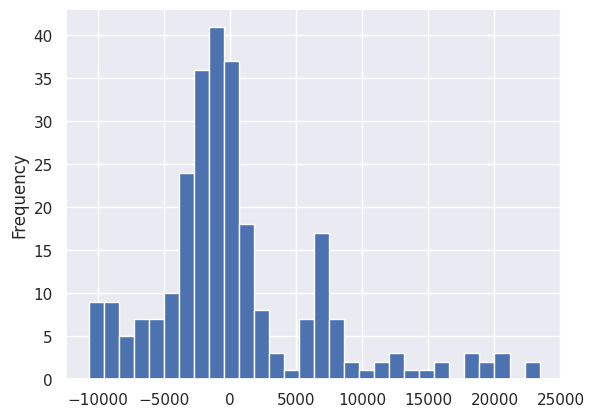

In [46]:
predictions.error.plot(kind='hist', bins=30)

In [47]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true, y_pred)
print(f'MAE wynosi: {mae:.2f}')

MAE wynosi: 4336.58


In [48]:
regressor.intercept_

np.float64(-12216.344892422187)

In [49]:
regressor.coef_

array([  256.8791,   344.1829,   480.2587,   -62.5121, 23702.5064,
        -473.2569,  -834.2698,  -852.8799])

In [50]:
data.columns

Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [51]:
import statsmodels.api as sm

X_train_ols = X_train.copy()
X_train_ols = X_train_ols.values
X_train_ols = sm.add_constant(X_train_ols)
X_train_ols

array([[1.0, 20, 33.0, ..., False, False, True],
       [1.0, 54, 31.9, ..., False, True, False],
       [1.0, 58, 41.91, ..., False, True, False],
       ...,
       [1.0, 18, 23.085, ..., False, False, False],
       [1.0, 24, 26.79, ..., True, False, False],
       [1.0, 23, 37.1, ..., False, False, True]], dtype=object)

In [67]:

X_tmp = pd.DataFrame(X_train_ols)
y_tmp = pd.Series(y_train)

X_tmp = X_tmp.apply(pd.to_numeric, errors='coerce')
y_tmp = pd.to_numeric(y_tmp, errors='coerce')

combined = pd.concat([X_tmp, y_tmp], axis=1).dropna()

X_clean = combined.iloc[:, :-1].astype(float)
y_clean = combined.iloc[:, -1].astype(float)

print(f"Pozostało wierszy: {len(X_clean)}")

ols = sm.OLS(y_clean, X_clean).fit()
print(ols.summary())

Pozostało wierszy: 858
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8873
Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.527
Time:                        18:14:13   Log-Likelihood:                -9263.8
No. Observations:                 858   AIC:                         1.855e+04
Df Residuals:                     849   BIC:                         1.859e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
0            1.06e+04   2418.

In [70]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

X_tmp = pd.DataFrame(X_train_ols).apply(pd.to_numeric, errors='coerce')
y_tmp = pd.Series(y_train).apply(pd.to_numeric, errors='coerce')

mask = X_tmp.notna().all(axis=1) & y_tmp.notna()
X_clean = X_tmp[mask].astype(float)
y_clean = y_tmp[mask].astype(float)

if len(X_clean) > 0:
    ols = sm.OLS(endog=y_clean, exog=X_clean).fit()

    if X_clean.shape[1] == len(X_train.columns) + 1:
        predictors = ['const'] + list(X_train.columns)
    else:
        predictors = list(X_train.columns)

    print(ols.summary(xname=predictors))
else:
    print("Błąd: Pusty zbiór danych po konwersji.")

/tmp/ipykernel_504/4030828567.py:9: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



ValueError: The indices for endog and exog are not aligned

In [69]:
X_selected = X_train_ols[:, [0, 1, 2, 3, 5, 6, 7, 8]]
predictors.remove('sex_male')

ols = sm.OLS(endog=y_train, exog=X_selected).fit()
print(ols.summary(xname=predictors))

KeyError: (slice(None, None, None), [0, 1, 2, 3, 5, 6, 7, 8])

In [ ]:
X_selected = X_train_ols[:, [0, 1, 2, 3, 5, 7, 8]]
predictors.remove('region_northwest')

ols = sm.OLS(endog=y_train, exog=X_selected).fit()
print(ols.summary(xname=predictors))

In [ ]:
X_selected = X_train_ols[:, [0, 1, 2, 3, 5, 7]]
predictors.remove('region_southwest')

ols = sm.OLS(endog=y_train, exog=X_selected).fit()
print(ols.summary(xname=predictors))